In [1]:
import os
import numpy as np
import pandas as pd


# NSL-KDD

In [2]:
## NSL-KDD
train_data = pd.read_csv('./dataset/nslkdd/KDDTrain+.txt', header=None)
test_data = pd.read_csv('./dataset/nslkdd/KDDTest+.txt', header=None)

In [3]:
columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
           'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
           'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
           'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
           'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
           'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
           'dst_host_srv_rerror_rate', 'attack', 'level']

train_data.columns = columns
test_data.columns = columns

In [4]:
full_data = pd.concat([train_data, test_data], ignore_index=True)

nsl_kdd_data = full_data

In [5]:
nsl_kdd_data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148512,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.00,0.00,0.00,normal,21
148513,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00,normal,21
148514,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.00,0.07,0.07,back,15
148515,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
# X = full_data.drop(['attack', 'level'], axis=1)
# y = full_data['attack']

In [7]:
# Get the count of each class in the 'attack' column
class_counts = nsl_kdd_data['attack'].value_counts()

# Print the counts for each class
print("Class counts:\n", class_counts)

# Compute the total sum of all counts
total_count = class_counts.sum()
print("\nTotal count of all classes:", total_count)


Class counts:
 attack
normal             77054
neptune            45871
satan               4368
ipsweep             3740
smurf               3311
portsweep           3088
nmap                1566
back                1315
guess_passwd        1284
mscan                996
warezmaster          964
teardrop             904
warezclient          890
apache2              737
processtable         685
snmpguess            331
saint                319
mailbomb             293
pod                  242
snmpgetattack        178
httptunnel           133
buffer_overflow       50
land                  25
multihop              25
rootkit               23
named                 17
ps                    15
sendmail              14
xterm                 13
imap                  12
ftp_write             11
loadmodule            11
xlock                  9
phf                    6
perl                   5
xsnoop                 4
spy                    2
worm                   2
sqlattack              2
udp

In [8]:
nsl_kdd_data['attack'].value_counts()/len(nsl_kdd_data)

attack
normal             0.518823
neptune            0.308860
satan              0.029411
ipsweep            0.025182
smurf              0.022294
portsweep          0.020792
nmap               0.010544
back               0.008854
guess_passwd       0.008645
mscan              0.006706
warezmaster        0.006491
teardrop           0.006087
warezclient        0.005993
apache2            0.004962
processtable       0.004612
snmpguess          0.002229
saint              0.002148
mailbomb           0.001973
pod                0.001629
snmpgetattack      0.001199
httptunnel         0.000896
buffer_overflow    0.000337
land               0.000168
multihop           0.000168
rootkit            0.000155
named              0.000114
ps                 0.000101
sendmail           0.000094
xterm              0.000088
imap               0.000081
ftp_write          0.000074
loadmodule         0.000074
xlock              0.000061
phf                0.000040
perl               0.000034
xsnoop       

In [9]:
# Multi-class classification: Each attack type gets its own class
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
nsl_kdd_data['attack'] = le.fit_transform(nsl_kdd_data['attack'])
print("Attack class mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i}: {label}")
nsl_kdd_data['attack'].value_counts().sort_index()

Attack class mapping:
  0: apache2
  1: back
  2: buffer_overflow
  3: ftp_write
  4: guess_passwd
  5: httptunnel
  6: imap
  7: ipsweep
  8: land
  9: loadmodule
  10: mailbomb
  11: mscan
  12: multihop
  13: named
  14: neptune
  15: nmap
  16: normal
  17: perl
  18: phf
  19: pod
  20: portsweep
  21: processtable
  22: ps
  23: rootkit
  24: saint
  25: satan
  26: sendmail
  27: smurf
  28: snmpgetattack
  29: snmpguess
  30: spy
  31: sqlattack
  32: teardrop
  33: udpstorm
  34: warezclient
  35: warezmaster
  36: worm
  37: xlock
  38: xsnoop
  39: xterm


attack
0       737
1      1315
2        50
3        11
4      1284
5       133
6        12
7      3740
8        25
9        11
10      293
11      996
12       25
13       17
14    45871
15     1566
16    77054
17        5
18        6
19      242
20     3088
21      685
22       15
23       23
24      319
25     4368
26       14
27     3311
28      178
29      331
30        2
31        2
32      904
33        2
34      890
35      964
36        2
37        9
38        4
39       13
Name: count, dtype: int64

In [10]:
nsl_kdd_data.drop(columns=['level'], inplace=True)

In [11]:
nsl_kdd_data['attack'].unique()

array([16, 14, 34,  7, 20, 32, 15, 25, 27, 19,  1,  4,  3, 12, 23,  2,  6,
       35, 18,  8,  9, 30, 17, 24, 11,  0, 28, 21,  5, 22, 29, 10, 13, 26,
       39, 36, 37, 38, 31, 33])

In [12]:
# nsl_kdd_data.drop(columns=['attack'], inplace=True)

# CICD-2017

In [18]:
import pandas as pd
# df1=pd.read_csv('./dataset/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
# df2=pd.read_csv('./dataset/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
# df3=pd.read_csv('./dataset/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv')
# df4=pd.read_csv('./dataset/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv')
# df5=pd.read_csv('./dataset/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv')
# df6=pd.read_csv('./dataset/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
# df7=pd.read_csv('./dataset/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv')
cicd2017 = pd.read_csv('./dataset/cicids/Wednesday-workingHours.pcap_ISCX.csv')

# cicd2017 = pd.concat([df1, df2, df3,df4,df5,df6,df7], ignore_index=True)

In [19]:
cicd2017[' Label'].unique()

array(['BENIGN', 'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk',
       'DoS GoldenEye', 'Heartbleed'], dtype=object)

# Utils and Pipeline Functions

In [20]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

def preprocess_data(dataframe):
    df = pd.DataFrame(dataframe)
    numeric_cols = df.select_dtypes(include=['number']).columns
    categorical_cols = df.select_dtypes(exclude=['number']).columns

    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=numeric_cols)
    df = df.dropna(subset=categorical_cols)

    if not categorical_cols.empty:
        df[categorical_cols] = df[categorical_cols].astype(str)
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])

    return df

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_curve_multi_class(test_y, probas, class_names):
    lb = label_binarize(test_y, classes=range(len(class_names)))

    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(lb[:, i], probas[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr['micro'], tpr['micro'], _ = roc_curve(lb.ravel(), probas.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= len(class_names)
    fpr['macro'] = all_fpr
    tpr['macro'] = mean_tpr
    roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr['micro'], tpr['micro'],
        label=f"Micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
        color='deeppink', linestyle=':', linewidth=1,
    )
    plt.plot(
        fpr['macro'], tpr['macro'],
        label=f"Macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
        color='navy', linestyle='-', linewidth=1,
    )

    for i, class_name in enumerate(class_names):
        plt.plot(
            fpr[i], tpr[i], lw=1,
            label=f"ROC curve of class {class_name} (AUC = {roc_auc[i]:.2f})"
        )

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-geometric

In [22]:


import torch
from torch_geometric.data import Data

c:\Users\ashis\.conda\envs\tf9\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\ashis\.conda\envs\tf9\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\ashis\.conda\envs\tf9\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
c:\Users\ashis\.conda\envs\tf9\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-

In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch.optim import Adam

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bigru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = x.unsqueeze(1)
        x, _ = self.bigru(x)
        x = x[:, -1, :]
        x = self.classifier(x)
        return x.squeeze(-1) if x.size(-1) == 1 else x

In [39]:
def run_all_benchmarks(train_X, test_X, train_y, test_y, train_graph, test_graph, k=10, class_weights=None):
    import os, gc, time, tracemalloc
    from sklearn.preprocessing import LabelBinarizer
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, roc_curve, classification_report, confusion_matrix
    )

    results = []
    all_auc_curves = {}
    X_train, X_test, y_train, y_test = train_X, test_X, train_y, test_y
    class_names = y_train.unique()

    lb = LabelBinarizer()
    lb.fit(train_y)

    # Graph model setup
    input_dim = train_graph.x.shape[1]
    output_dim = 1 if len(train_graph.y.unique()) == 2 else len(train_graph.y.unique())

    gnn_models = {
        "GCN": GCN(input_dim, hidden_dim=64, output_dim=output_dim)
    }

    confusion_matrices = {}
    for name, model in gnn_models.items():
        os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
        gc.collect()
        torch.cuda.empty_cache()
        print(f"\n--- Training {name} ---")
        model = model.to(device)
        tracemalloc.start()
        start_time = time.time()

        # Standard training loop
        optimizer = Adam(model.parameters(), lr=0.001)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
        weights_for_loss = None
        if class_weights is not None and len(class_names) > 2:
            weights_for_loss = class_weights.to(device)
            if weights_for_loss.numel() != output_dim:
                weights_for_loss = None
        model.train()
        for epoch in range(300):
            optimizer.zero_grad()
            out_train = model(train_graph.x, train_graph.edge_index)
            if len(class_names) == 2:
                loss = F.binary_cross_entropy_with_logits(
                    out_train[train_graph.train_mask].squeeze(),
                    train_graph.y[train_graph.train_mask].float()
                )
            else:
                loss = F.cross_entropy(
                    out_train[train_graph.train_mask].squeeze(),
                    train_graph.y[train_graph.train_mask].long(),
                    weight=weights_for_loss
                )
            loss.backward()
            optimizer.step()
            scheduler.step()

        # Evaluation
        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)

            if len(class_names) == 2:
                probas = torch.sigmoid(out).cpu().numpy()
                if probas.ndim > 1 and probas.shape[1] == 1:
                    probas_pos = probas[:, 0]
                else:
                    probas_pos = probas.ravel()
                pred = (probas_pos > 0.5).astype(int)
            else:
                probas = torch.softmax(out, dim=1).cpu().numpy()
                pred = probas.argmax(axis=1)

        # Make sure pred and probas variables exist for metrics
        # For binary: use probas_pos (1d array), for multiclass use probas (N x C)
        if len(class_names) == 2:
            # Ensure arrays are 1-D numpy arrays
            y_true = np.asarray(y_test)
            y_pred = np.asarray(pred).ravel()
            y_proba_for_auc = np.asarray(probas_pos).ravel()
        else:
            y_true = np.asarray(y_test)
            y_pred = np.asarray(pred).ravel()
            y_proba_for_auc = np.asarray(probas)  # shape (N, C)

        # Metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        confusion = confusion_matrix(y_true, y_pred)

        # Store confusion matrix for later visualization
        confusion_matrices[name] = confusion

        # AUC (guarded — roc_auc_score throws if only one class present)
        auc = None
        try:
            if len(class_names) == 2:
                # roc_auc expects shape (n_samples,) of positive probabilities
                auc = roc_auc_score(y_true, y_proba_for_auc)
                fpr, tpr, _ = roc_curve(y_true, y_proba_for_auc)
                all_auc_curves[name] = (fpr, tpr, auc)
            else:
                # multiclass: probas should be shape (N, C)
                auc = roc_auc_score(y_true, y_proba_for_auc, multi_class='ovr', average='macro')
                fpr_dict, tpr_dict, auc_dict = {}, {}, {}
                y_b = lb.transform(y_true)
                for i in range(len(class_names)):
                    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_b[:, i], y_proba_for_auc[:, i])
                    auc_dict[i] = roc_auc_score(y_b[:, i], y_proba_for_auc[:, i])
                all_auc_curves[name] = (fpr_dict, tpr_dict, auc_dict)
        except ValueError:
            # Could happen if only one class present in y_true; keep auc = None
            auc = None

        end_time = time.time()
        mem_consumption = tracemalloc.get_traced_memory()[1]
        tracemalloc.stop()

        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "AUC": auc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Classification Report": report,
            "Confusion Matrix": confusion,
            "Time (s)": f"{end_time - start_time:.2f} s",
            "Memory (MB)": f"{mem_consumption / 1e6:.2f} MB"
        })

        # cleanup per-model
        out = out.cpu() if isinstance(out, torch.Tensor) else out
        del out
        torch.cuda.empty_cache()

    results_df = pd.DataFrame(results).drop(columns=["Classification Report", "Confusion Matrix"])
    results_df = results_df.sort_values("Accuracy", ascending=False)
    print("\nBenchmark Results:")
    print(results_df.to_markdown(index=False))

    return results_df, confusion_matrices


In [25]:
# Graph helper functions (placed before experiments for sequential execution)
def adaptive_graph_construction(X, y, adaptive_metric='euclidean', threshold=0.5):
    from sklearn.metrics.pairwise import pairwise_distances
    distances = pairwise_distances(X, metric=adaptive_metric)
    adj = (distances < threshold).astype(int)
    adj = kneighbors_graph(X, 20, metric='euclidean').toarray() * adj
    edge_index = torch.tensor(adj.nonzero(), dtype=torch.long)
    features = torch.tensor(X, dtype=torch.float)
    labels = torch.tensor(y, dtype=torch.long)
    return Data(x=features, edge_index=edge_index, y=labels)

def augment_graph(data, edge_perturbation_rate=0.1, feature_mask_rate=0.2):
    num_edges = data.edge_index.size(1)
    num_perturb = int(edge_perturbation_rate * num_edges)
    if num_perturb > 0:
        random_indices = torch.randint(0, num_edges, (num_perturb,))
        data.edge_index = torch.cat([data.edge_index[:, random_indices], data.edge_index], dim=1)

    num_features = data.x.size(1)
    num_mask = int(feature_mask_rate * num_features)
    if num_mask > 0:
        random_features = torch.randint(0, num_features, (num_mask,))
        data.x[:, random_features] = 0
    return data

# Experiments

Using device: cpu

Processing dataset: UNSW-NB15
Shape of UNSW-NB15: (257673, 193)
Number of unique classes in 'attack_cat': 10


np.int64(257673)


Class mapping for UNSW-NB15:
  Class 0: Analysis
  Class 1: Backdoor
  Class 2: DoS
  Class 3: Exploits
  Class 4: Fuzzers
  Class 5: Generic
  Class 6: Normal
  Class 7: Reconnaissance
  Class 8: Shellcode
  Class 9: Worms


attack_cat
0     2677
1     2329
2    16353
3    44525
4    24246
5    58871
6    93000
7    13987
8     1511
9      174
Name: count, dtype: int64

attack_cat
0    1500
1    1500
2    1500
3    1500
4    1500
5    1500
6    1500
7    1500
8    1500
9    1500
Name: count, dtype: int64
done

--- Training GCN ---

Benchmark Results:
| Model   |   Accuracy |     AUC |   Precision |   Recall |       F1 | Time (s)   | Memory (MB)   |
|:--------|-----------:|--------:|------------:|---------:|---------:|:-----------|:--------------|
| GCN     |   0.593667 | 0.91606 |    0.599972 | 0.593667 | 0.590981 | 36.35 s    | 0.79 MB       |

CONFUSION MATRICES FOR UNSW-NB15 (PERCENT)


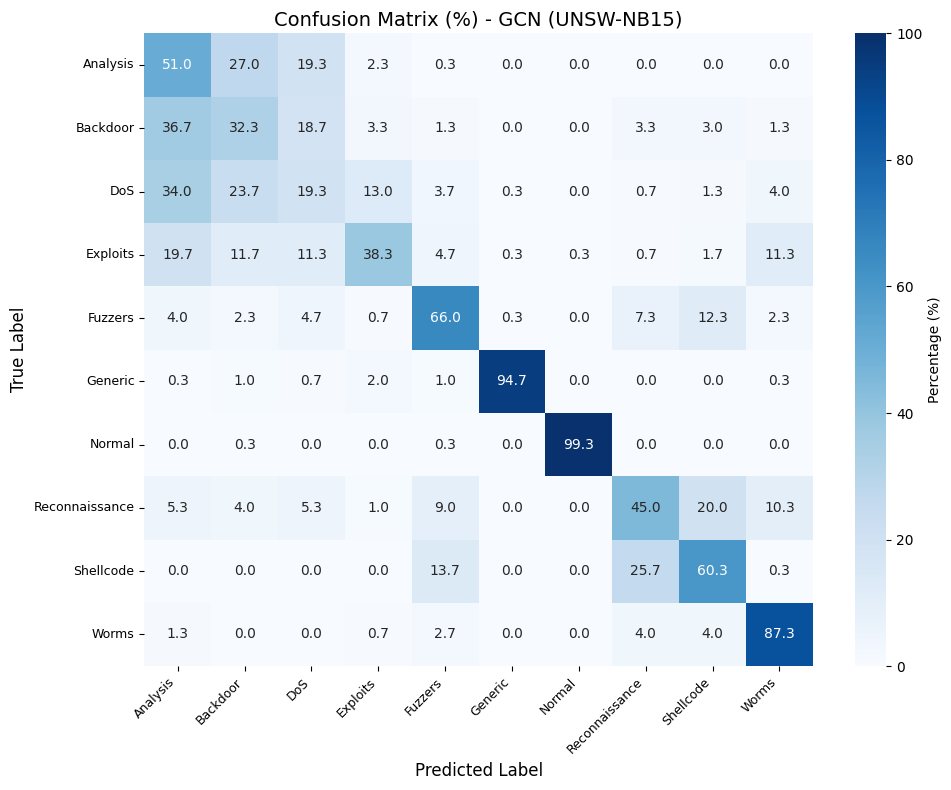

,Model,Accuracy,AUC,Precision,Recall,F1,Time (s),Memory (MB)
0,GCN,0.593667,0.91606,0.599972,0.593667,0.590981,36.35 s,0.79 MB



Processing dataset: CICIDS2017
Shape of CICIDS2017: (690109, 85)
Number of unique classes in ' Label': 6


np.int64(690109)


Class mapping for CICIDS2017:
  Class 0: BENIGN
  Class 1: DoS GoldenEye
  Class 2: DoS Hulk
  Class 3: DoS Slowhttptest
  Class 4: DoS slowloris
  Class 5: Heartbleed


 Label
0    438446
1     10233
2    230124
3      5499
4      5796
5        11
Name: count, dtype: int64

 Label
0    3176
1      74
2    1667
3      39
4      41
5      11
Name: count, dtype: int64
done

--- Training GCN ---

Benchmark Results:
| Model   |   Accuracy |      AUC |   Precision |   Recall |       F1 | Time (s)   | Memory (MB)   |
|:--------|-----------:|---------:|------------:|---------:|---------:|:-----------|:--------------|
| GCN     |   0.988024 | 0.979116 |    0.924318 | 0.851491 | 0.873867 | 11.85 s    | 0.35 MB       |

CONFUSION MATRICES FOR CICIDS2017 (PERCENT)


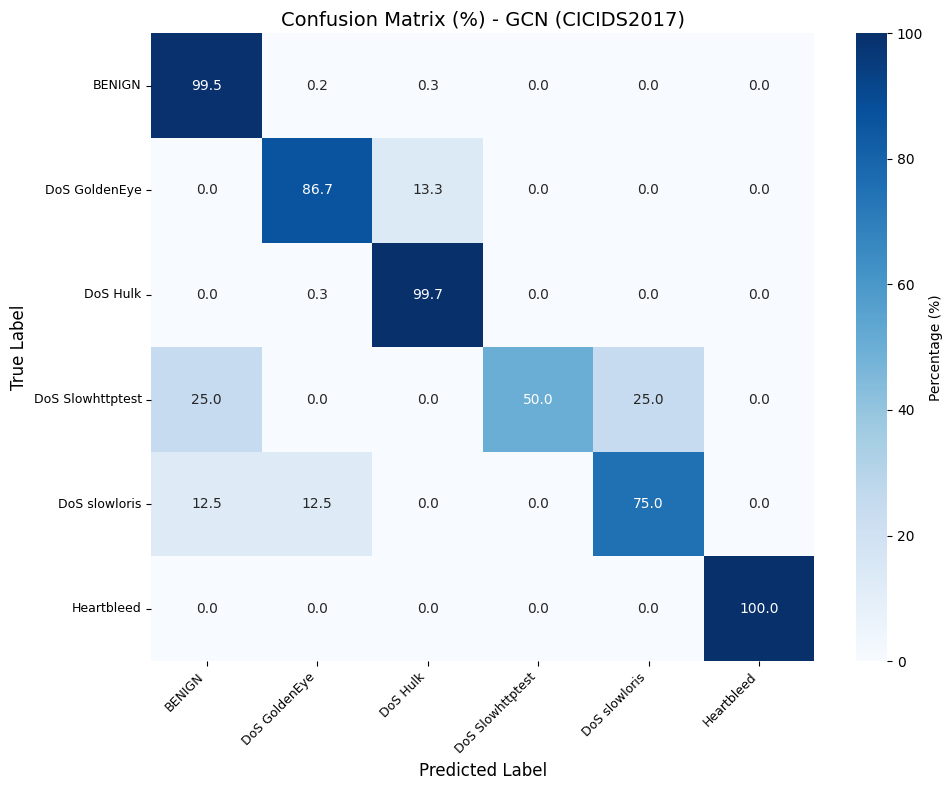

,Model,Accuracy,AUC,Precision,Recall,F1,Time (s),Memory (MB)
0,GCN,0.988024,0.979116,0.924318,0.851491,0.873867,11.85 s,0.35 MB



Processing dataset: NSL-KDD
Shape of NSL-KDD: (148515, 43)
Number of unique classes in 'attack': 5


np.int64(148515)


Class mapping for NSL-KDD:
  Class 0: DoS
  Class 1: R2L
  Class 2: U2R
  Class 3: normal
  Class 4: probing


attack
0    53385
1     3880
2      119
3    77054
4    14077
Name: count, dtype: int64

attack
0    1798
1     130
2     119
3    2596
4     474
Name: count, dtype: int64
done

--- Training GCN ---

Benchmark Results:
| Model   |   Accuracy |      AUC |   Precision |   Recall |       F1 | Time (s)   | Memory (MB)   |
|:--------|-----------:|---------:|------------:|---------:|---------:|:-----------|:--------------|
| GCN     |   0.978516 | 0.997037 |     0.89544 |  0.88069 | 0.887676 | 14.64 s    | 0.34 MB       |

CONFUSION MATRICES FOR NSL-KDD (PERCENT)


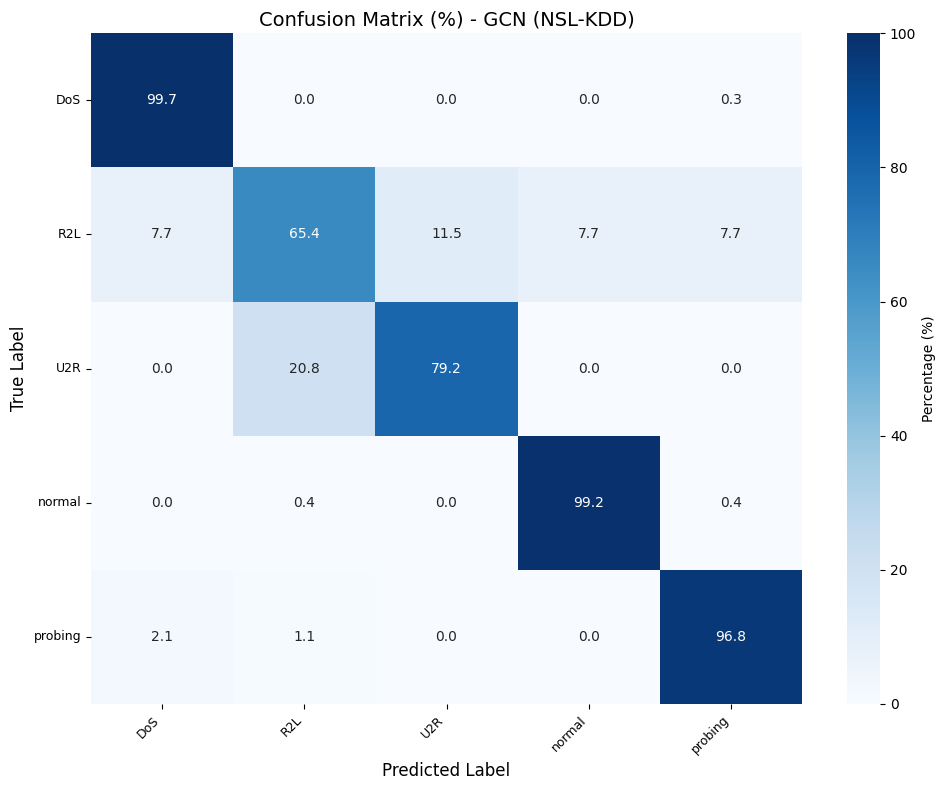

,Model,Accuracy,AUC,Precision,Recall,F1,Time (s),Memory (MB)
0,GCN,0.978516,0.997037,0.89544,0.88069,0.887676,14.64 s,0.34 MB


In [ ]:
import os
import gc
from sklearn.preprocessing import LabelEncoder
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Reload NSL-KDD fresh to get original attack type names (not numeric codes)
nsl_columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
           'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
           'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
           'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
           'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
           'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
           'dst_host_srv_rerror_rate', 'attack', 'level']

nsl_train = pd.read_csv('./dataset/nslkdd/KDDTrain+.txt', header=None)
nsl_test = pd.read_csv('./dataset/nslkdd/KDDTest+.txt', header=None)
nsl_train.columns = nsl_columns
nsl_test.columns = nsl_columns
nsl_kdd_fresh = pd.concat([nsl_train, nsl_test], ignore_index=True)

datasets = {
    "CICIDS2017": cicd2017,
    "NSL-KDD": nsl_kdd_fresh,
}

target_columns = {
    "NSL-KDD": 'attack',
    "CICIDS2017": ' Label',
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

for dataset_name, path in datasets.items():
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    torch.cuda.empty_cache()

    print(f"\nProcessing dataset: {dataset_name}")
    target_col = target_columns[dataset_name]

    temp = path.copy()
    original_target = temp[target_col].copy()
    df = preprocess_data(temp)
    df[target_col] = original_target.iloc[:len(df)].reset_index(drop=True)

    if dataset_name == "NSL-KDD":
        dos_attacks = {
            'back', 'land', 'neptune', 'pod', 'smurf', 'teardrop',
            'apache2', 'mailbomb', 'processtable', 'udpstorm'
        }
        probing_attacks = {
            'ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint'
        }
        u2r_attacks = {
            'buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'sqlattack', 'xterm', 'ps'
        }
        r2l_attacks = {
            'ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy',
            'warezclient', 'warezmaster', 'httptunnel', 'named', 'sendmail',
            'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop'
        }

        def map_nsl_attack(label):
            label = str(label).strip()
            if label == 'normal':
                return 'normal'
            if label in probing_attacks:
                return 'probing'
            if label in dos_attacks:
                return 'DoS'
            if label in u2r_attacks:
                return 'U2R'
            if label in r2l_attacks:
                return 'R2L'
            return np.nan

        df[target_col] = df[target_col].apply(map_nsl_attack)

    df = df.dropna(subset=[target_col]).reset_index(drop=True)

    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    print(f"Shape of {dataset_name}: {df.shape}")
    print(f"Number of unique classes in '{target_col}': {len(df[target_col].unique())}")
    display(df[target_col].value_counts().sum())

    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col].astype(str))

    print(f"\nClass mapping for {dataset_name}:")
    class_names = le.classes_
    for idx, label in enumerate(class_names):
        print(f"  Class {idx}: {label}")

    display(df[target_col].value_counts().sort_index())

    def create_imbalanced_subset(df, target_col, new_dataset_size=5000):
        class_counts = df[target_col].value_counts()
        large_classes = class_counts[class_counts > 500]
        small_classes = class_counts[class_counts <= 500]

        total_large_samples = large_classes.sum()
        scaled_counts = (large_classes / total_large_samples * new_dataset_size).astype(int)

        sampled_data = []
        for class_label, original_count in large_classes.items():
            sample_size = min(scaled_counts[class_label], original_count)
            sampled_class = df[df[target_col] == class_label].sample(n=sample_size, random_state=42)
            sampled_data.append(sampled_class)

        for class_label in small_classes.index:
            sampled_data.append(df[df[target_col] == class_label])

        return pd.concat(sampled_data).reset_index(drop=True)

    df = create_imbalanced_subset(df, target_col=target_col, new_dataset_size=5000)
    print(df[target_col].value_counts().sort_index())

    X = df.drop(columns=[target_col])
    y = df[target_col]

    numeric_cols = X.select_dtypes(include=["number"]).columns
    scaler = StandardScaler()
    scaler = scaler.fit(X[numeric_cols])
    X = pd.DataFrame(scaler.transform(X[numeric_cols]))

    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    def introduce_feature_correlation(X, correlation_level=0.8):
        num_features = X.shape[1]
        correlation_matrix = np.random.uniform(correlation_level, 1.0, (num_features, num_features))
        X_correlated = np.dot(X, correlation_matrix)
        return X_correlated

    train_X1 = introduce_feature_correlation(train_X, correlation_level=0.9)
    test_X1 = introduce_feature_correlation(test_X, correlation_level=0.9)

    from sklearn.feature_selection import mutual_info_classif

    def drop_strong_features(X, y, keep_ratio=0.3):
        mi = mutual_info_classif(X, y)
        important_features = np.argsort(mi)[-int(len(mi) * keep_ratio):]
        return X[:, important_features]

    train_X1 = drop_strong_features(train_X1, train_y, keep_ratio=0.3)
    test_X1 = drop_strong_features(test_X1, test_y, keep_ratio=0.3)

    train_X1 = pd.DataFrame(train_X1)
    test_X1 = pd.DataFrame(test_X1)

    train_graph = adaptive_graph_construction(train_X.values, train_y.values, adaptive_metric='euclidean', threshold=0.5)
    test_graph = adaptive_graph_construction(test_X.values, test_y.values, adaptive_metric='euclidean', threshold=0.5)

    train_graph.train_mask = torch.zeros(len(train_y), dtype=torch.bool)
    train_graph.train_mask[:int(0.9 * len(train_y))] = True
    test_graph.test_mask = torch.zeros(test_graph.num_nodes, dtype=torch.bool)
    print("done")

    train_graph.x = train_graph.x.to(device)
    train_graph.edge_index = train_graph.edge_index.to(device)
    train_graph.y = train_graph.y.to(device)

    test_graph.x = test_graph.x.to(device)
    test_graph.edge_index = test_graph.edge_index.to(device)

    del df, X, y
    torch.cuda.empty_cache()
    gc.collect()

    results_df, confusion_matrices = run_all_benchmarks(
        train_X1,
        test_X1,
        train_y,
        test_y,
        train_graph,
        test_graph,
        k=10,
        class_weights=None,
    )

    import seaborn as sns
    print(f"\n{'='*70}")
    print(f"CONFUSION MATRICES FOR {dataset_name} (PERCENT)")
    print(f"{'='*70}")

    for model_name, conf_matrix in confusion_matrices.items():
        n_classes = len(class_names)
        figsize = (max(10, n_classes * 0.5), max(8, n_classes * 0.5))

        row_sums = conf_matrix.sum(axis=1, keepdims=True)
        conf_matrix_pct = np.divide(
            conf_matrix.astype(float),
            row_sums,
            out=np.zeros_like(conf_matrix, dtype=float),
            where=row_sums != 0,
        ) * 100

        plt.figure(figsize=figsize)
        sns.heatmap(
            conf_matrix_pct,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            cbar=True,
            vmin=0,
            vmax=100,
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Percentage (%)'},
        )
        plt.title(f'Confusion Matrix (%) - {model_name} ({dataset_name})', fontsize=14)
        plt.ylabel('True Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()

    del train_X1, test_X1, train_y, test_y, train_graph, test_graph
    display(results_df)